In [40]:
import pandas as pd

df = pd.read_csv('../data/customer_support_tickets.csv')

print(df.shape)

df.head()

(8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [41]:
print(df.columns.tolist())

['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


In [42]:
# 1. Import Libraries
# 2. Load Dataset
# 3. Exploratory Data Analysis
# 4. Text Preprocessing
# 5. TF-IDF Vectorization
# 6. Ticket Type Classification
# 7. Ticket Priority Classification
# 8. Evaluation Metrics
# 9. Confusion Matrix
# 10. Save Models
# 11. Custom Ticket Testing

In [74]:
import pandas as pd
import numpy as np

import nltk
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [44]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SATHWIK\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [45]:
df = pd.read_csv('../data/customer_support_tickets.csv')

print("Shape:", df.shape)

df.head()

Shape: (8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [46]:
df[['Ticket Description',
    'Ticket Type',
    'Ticket Priority']].head()

,Ticket Description,Ticket Type,Ticket Priority
0,I'm having an issue with the {product_purchase...,Technical issue,Critical
1,I'm having an issue with the {product_purchase...,Technical issue,Critical
2,I'm facing a problem with my {product_purchase...,Technical issue,Low
3,I'm having an issue with the {product_purchase...,Billing inquiry,Low
4,I'm having an issue with the {product_purchase...,Billing inquiry,Low


In [47]:
df[['Ticket Description',
    'Ticket Type',
    'Ticket Priority']].isnull().sum()

Ticket Description    0
Ticket Type           0
Ticket Priority       0
dtype: int64

In [48]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [49]:
df['combined_text'] = (
    df['Ticket Subject'].fillna('') + ' ' +
    df['Ticket Description'].fillna('')
)

df['clean_text'] = df['combined_text'].apply(clean_text)

df[['Ticket Subject',
    'Ticket Description',
    'clean_text']].head()

,Ticket Subject,Ticket Description,clean_text
0,Product setup,I'm having an issue with the {product_purchase...,product setup im issue productpurchased please...
1,Peripheral compatibility,I'm having an issue with the {product_purchase...,peripheral compatibility im issue productpurch...
2,Network problem,I'm facing a problem with my {product_purchase...,network problem im facing problem productpurch...
3,Account access,I'm having an issue with the {product_purchase...,account access im issue productpurchased pleas...
4,Data loss,I'm having an issue with the {product_purchase...,data loss im issue productpurchased please ass...


In [50]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words='english'
)

X = tfidf.fit_transform(
    df['clean_text']
)

print(X.shape)

(8469, 10000)


In [51]:
y_category = df['Ticket Type']

In [52]:
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X,
    y_category,
    test_size=0.2,
    random_state=42
)

In [75]:
category_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

category_model.fit(
    X_train_cat,
    y_train_cat
)

category_pred = category_model.predict(
    X_test_cat
)

In [76]:
category_pred = category_model.predict(
    X_test_cat
)

print(
    "Category Accuracy:",
    accuracy_score(
        y_test_cat,
        category_pred
    )
)

Category Accuracy: 0.20720188902007083


In [55]:
print(
    classification_report(
        y_test_cat,
        category_pred
    )
)

                      precision    recall  f1-score   support

     Billing inquiry       0.20      0.15      0.17       357
Cancellation request       0.18      0.18      0.18       327
     Product inquiry       0.20      0.21      0.20       316
      Refund request       0.16      0.17      0.17       345
     Technical issue       0.24      0.26      0.25       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.19      1694
        weighted avg       0.20      0.20      0.19      1694



In [56]:
y_priority = df['Ticket Priority']

In [57]:
X_train_pri, X_test_pri, y_train_pri, y_test_pri = train_test_split(
    X,
    y_priority,
    test_size=0.2,
    random_state=42
)

In [77]:
priority_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

priority_model.fit(
    X_train_pri,
    y_train_pri
)

priority_pred = priority_model.predict(
    X_test_pri
)

In [78]:
priority_pred = priority_model.predict(
    X_test_pri
)

print(
    "Priority Accuracy:",
    accuracy_score(
        y_test_pri,
        priority_pred
    )
)

Priority Accuracy: 0.2650531286894923


In [60]:
print(
    classification_report(
        y_test_pri,
        priority_pred
    )
)

              precision    recall  f1-score   support

    Critical       0.24      0.26      0.25       411
        High       0.25      0.26      0.25       409
         Low       0.23      0.23      0.23       415
      Medium       0.29      0.27      0.28       459

    accuracy                           0.25      1694
   macro avg       0.25      0.25      0.25      1694
weighted avg       0.25      0.25      0.25      1694



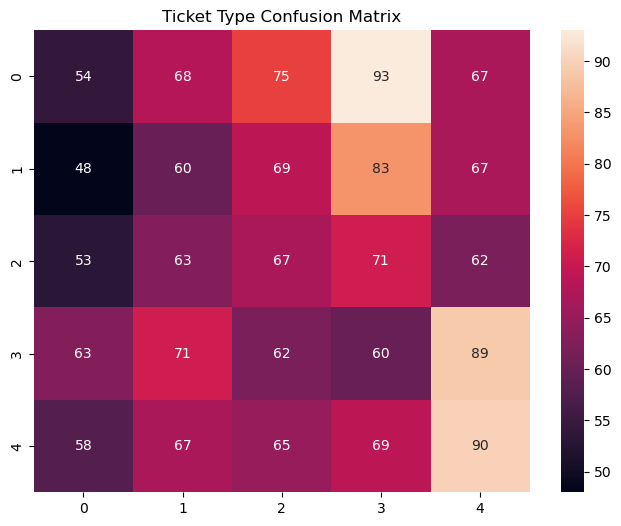

In [61]:
cm = confusion_matrix(
    y_test_cat,
    category_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Ticket Type Confusion Matrix")

plt.show()

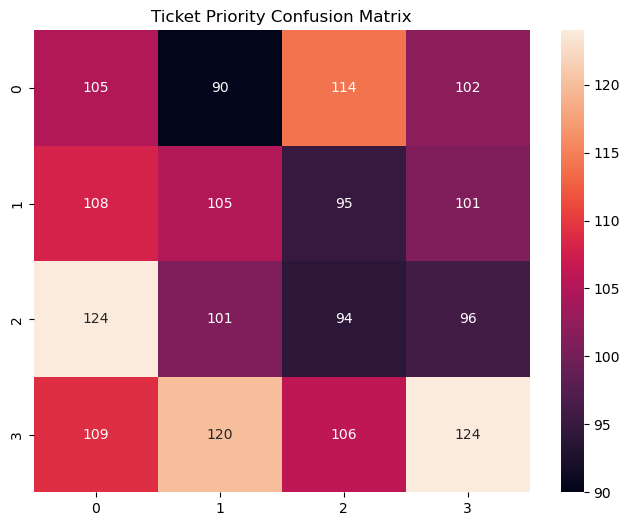

In [62]:
cm = confusion_matrix(
    y_test_pri,
    priority_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Ticket Priority Confusion Matrix")

plt.show()

In [63]:
joblib.dump(
    category_model,
    '../models/category_model.pkl'
)

joblib.dump(
    priority_model,
    '../models/priority_model.pkl'
)

joblib.dump(
    tfidf,
    '../models/tfidf_vectorizer.pkl'
)

['../models/tfidf_vectorizer.pkl']

In [64]:
ticket = """
My payment was deducted twice
but premium subscription
is not activated.
"""

cleaned = clean_text(ticket)

vector = tfidf.transform([cleaned])

category = category_model.predict(vector)

priority = priority_model.predict(vector)

print("Category :", category[0])
print("Priority :", priority[0])

Category : Technical issue
Priority : Critical


In [65]:
print(df['Ticket Type'].value_counts())

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


In [66]:
print(df['Ticket Priority'].value_counts())

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


In [67]:
print(df['Ticket Subject'].head(20))

0                Product setup
1     Peripheral compatibility
2              Network problem
3               Account access
4                    Data loss
5                Payment issue
6               Refund request
7                 Battery life
8         Installation support
9                Payment issue
10                   Data loss
11                Software bug
12              Hardware issue
13               Product setup
14               Product setup
15      Product recommendation
16              Account access
17               Payment issue
18    Peripheral compatibility
19                Software bug
Name: Ticket Subject, dtype: object


In [68]:
print(df['Ticket Description'].head(5))

0    I'm having an issue with the {product_purchase...
1    I'm having an issue with the {product_purchase...
2    I'm facing a problem with my {product_purchase...
3    I'm having an issue with the {product_purchase...
4    I'm having an issue with the {product_purchase...
Name: Ticket Description, dtype: object


In [69]:
print(df[['Ticket Subject',
          'Ticket Type']].head(20))

              Ticket Subject           Ticket Type
0              Product setup       Technical issue
1   Peripheral compatibility       Technical issue
2            Network problem       Technical issue
3             Account access       Billing inquiry
4                  Data loss       Billing inquiry
5              Payment issue  Cancellation request
6             Refund request       Product inquiry
7               Battery life        Refund request
8       Installation support       Technical issue
9              Payment issue        Refund request
10                 Data loss  Cancellation request
11              Software bug       Product inquiry
12            Hardware issue       Technical issue
13             Product setup       Technical issue
14             Product setup       Billing inquiry
15    Product recommendation       Billing inquiry
16            Account access       Product inquiry
17             Payment issue       Product inquiry
18  Peripheral compatibility   

In [71]:
print("Category Accuracy:", accuracy_score(y_test_cat, category_pred))
print("Priority Accuracy:", accuracy_score(y_test_pri, priority_pred))

Category Accuracy: 0.19539551357733176
Priority Accuracy: 0.2526564344746163


In [72]:
print(classification_report(y_test_cat, category_pred))

                      precision    recall  f1-score   support

     Billing inquiry       0.20      0.15      0.17       357
Cancellation request       0.18      0.18      0.18       327
     Product inquiry       0.20      0.21      0.20       316
      Refund request       0.16      0.17      0.17       345
     Technical issue       0.24      0.26      0.25       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.19      1694
        weighted avg       0.20      0.20      0.19      1694



In [73]:
print(classification_report(y_test_pri, priority_pred))

              precision    recall  f1-score   support

    Critical       0.24      0.26      0.25       411
        High       0.25      0.26      0.25       409
         Low       0.23      0.23      0.23       415
      Medium       0.29      0.27      0.28       459

    accuracy                           0.25      1694
   macro avg       0.25      0.25      0.25      1694
weighted avg       0.25      0.25      0.25      1694



In [79]:
print(df['Ticket Type'].nunique())
print(df['Ticket Type'].unique())

5
['Technical issue' 'Billing inquiry' 'Cancellation request'
 'Product inquiry' 'Refund request']


In [80]:
print(df['Ticket Priority'].unique())

['Critical' 'Low' 'High' 'Medium']


In [81]:
pd.set_option('display.max_colwidth', None)

for i in range(5):
    print(f"\n--- Ticket {i} ---")
    print(df['Ticket Description'].iloc[i])


--- Ticket 0 ---
I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.

--- Ticket 1 ---
I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_purchased}. Please assist.

If The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.

--- Ticket 2 ---
I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.

1.8.3 I really I'm using the original charger that came with my {product_purchased}, but it's not charging properly.

--- Ticket 3 ---
I'm having an issue with the {product_purchased}. Please assist.

If you have a prob

In [82]:
print(df['Ticket Description'].str.len().describe())

count    8469.000000
mean      289.821939
std        43.593954
min       151.000000
25%       273.000000
50%       298.000000
75%       318.000000
max       397.000000
Name: Ticket Description, dtype: float64


In [85]:
X_train = pd.read_csv('../data/zenodo_dataset/X_train.csv')
X_test = pd.read_csv('../data/zenodo_dataset/X_test.csv')

y_train = pd.read_csv('../data/zenodo_dataset/y_train.csv')
y_test = pd.read_csv('../data/zenodo_dataset/y_test.csv')

In [87]:
print(X_train.head())
print(X_train.shape)

     id  \
0  1919   
1  1584   
2   584   
3  1393   
4  8636   

                                                                                                                                                        text  
0                                                                                   File Share Access - [TICKET ID] - [NAME]. [NAME] ([COMPANY]. [LOCATION])  
1                                                                                          File Share Access - [TICKET ID] - [NAME] ([COMPANY]A. [LOCATION])  
2                               [TICKET ID] - A Support Ticket was forwarded to your role  - Leaving Employee - [TICKET ID] - [NAME] ([COMPANY]. [LOCATION])  
3  [TICKET ID] - A Support Ticket was forwarded to your role  - check_mk SD Hostalarm: ([LOCATION]-WSUS01) [COMPANY] [SERVER] -[LOCATION]Server - UP -> DOWN  
4                                                                                       LVS not respondingLVS will not except my password 

In [88]:
print(y_train.head())
print(y_train.shape)

     id   category_truth
0  1919      Fileservice
1  1584      Fileservice
2   584  Support general
3  1393  Support general
4  8636      Fileservice
(1572, 2)
